In [1]:
from plot_osc import *
from create_system_matrix import *
from bat_class import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#%% PLOT SETTINGS
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'grid.alpha': 0.3,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
    'axes.facecolor': '#F1F5F2',
    'axes.grid': True
})

colors = plt.get_cmap('tab10').colors
#turn colors into a list
colors = [colors[i] for i in range(len(colors))]
colors = ['#EFA00B', '#439775', '#4B4E6D', '#6A4C93', '#FAC8CD', '#9BC1BC', '#5D737E', '#D9BF77', '#ACD8AA', '#FFE156']

In [3]:
N = 50
dz = 0.01
z = np.arange(0, N*dz, dz) + dz
#Ri is an 2 by N array, (z in cm, diameter in mm)
Ri = np.zeros((N, 2))
Ri[:, 0] = z * 100       # convert m to cm (BatOsc expects cm)
Ri[:, 1] = 60  # radius 0.3m -> diameter in mm (BatOsc expects mm)
Y = 1.814 * 1e10 # in N/m^2
S = 1.05 * 1e9 # in N/m^2
rho = 649 # in kg/m^3
m = rho * np.pi * 0.3**2 * dz  # mass per slice (kg)

cylinder = BatOsc(Ri, dz)
cylinder.set_bat_features(m, rho, Y, S)

In [4]:
z

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 ])

No solution found, plotting static bat.


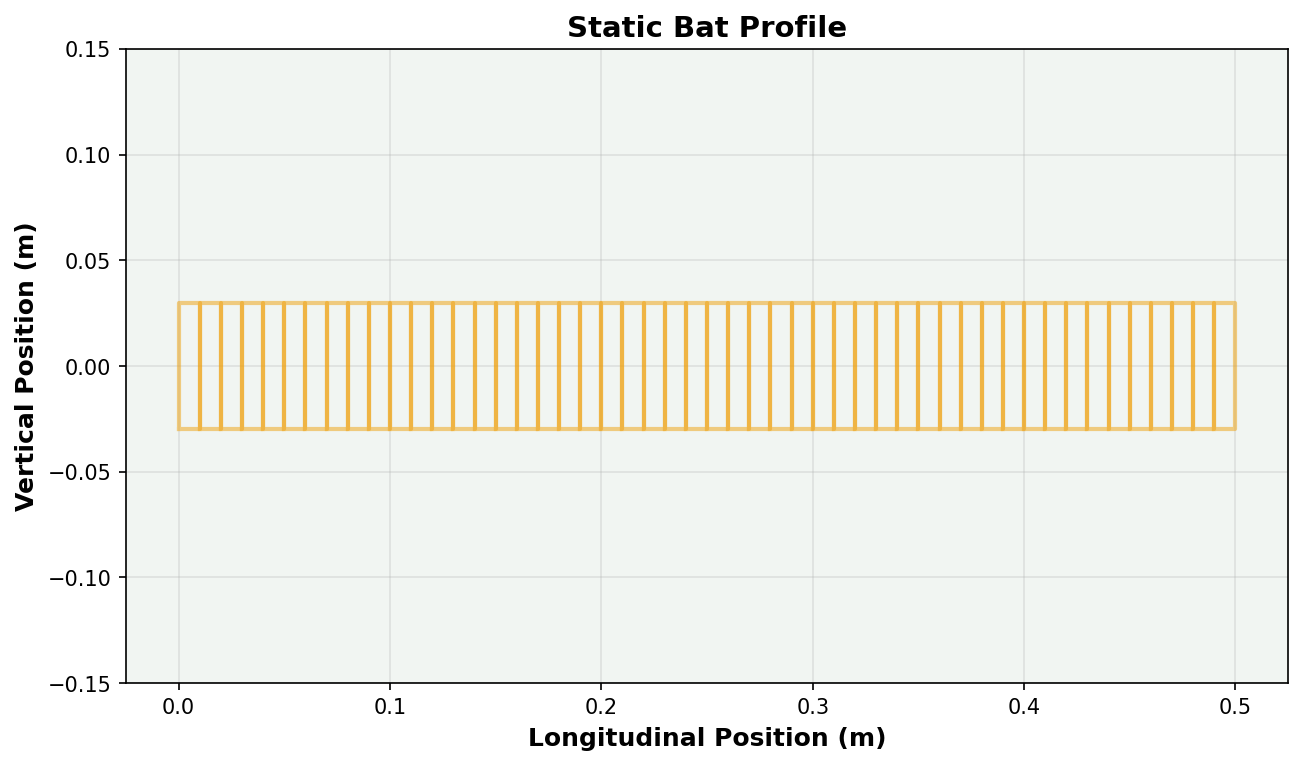

In [5]:
plot_bat(cylinder, z, colors[0], 'Cylindrical Bat')

In [36]:
L = N * dz  # total length of cylinder
t_array = np.linspace(0, 2, 1000)  # 0 to 2s

# Standing wave: 4 nodes (n=3) at f=2Hz
A = 0.1
f = 2  # Hz
spatial = np.sin(3 * np.pi * z / L)
temporal = np.sin(2 * np.pi * f * t_array)

# shape: (N, len(t_array))
standing_wave = A * np.outer(spatial, temporal)

In [37]:
def standing_wave(nodes, f, A = 0.05, L = N*dz):
    z = np.arange(0, L, dz) + dz
    spatial = np.sin(nodes * np.pi * z / L)
    temporal = np.sin(2 * np.pi * f * t_array)
    return A * np.outer(spatial, temporal)

In [45]:
def new_animate(bat_sol, path = None, interval = 50, idx = 25, nodes  = []):
    if not hasattr(bat_sol, 'y_sol') or not hasattr(bat_sol, 'phi_sol'):
        print('No solution found, cannot animate bat.')
        return
    if interval < 1:
        raise ValueError("interval must be >= 1")

    frame_indices = np.arange(0, bat_sol.y_sol.shape[1], interval)
    num_frames = len(frame_indices)

    base_ylim = max(bat_sol.radii) * 1.2
    max_disp = np.max(np.abs(bat_sol.y_sol))
    y_lim = max(base_ylim, max_disp + base_ylim)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_aspect('equal')
    
    ax.set_ylabel('Forward-Backward Position (m)')
    ax.set_xlabel('Longitudinal Position (m)')
    ax.set_ylim(-y_lim, y_lim)
    ax.set_xlim(min(bat_sol.zs)-bat_sol.dz, max(bat_sol.zs)+3*bat_sol.dz)

    def update(frame):
        t_idx = frame_indices[frame]
        ax.clear()
        ax.set_aspect('equal')
        ax.set_ylabel('Forward-Backward Position (m)')
        ax.set_xlabel('Longitudinal Position (m)')
        ax.set_ylim(-y_lim, y_lim)
        ax.set_xlim(min(bat_sol.zs)-bat_sol.dz, max(bat_sol.zs)+3*bat_sol.dz)
        for i in range(bat_sol.N):
            y_val = bat_sol.y_sol[i, t_idx]
            phi_val =  bat_sol.phi_sol[i, t_idx]
            box = get_box(bat_sol, i, y_shift=y_val, phi=phi_val)
            ax.plot(box[:, 0], box[:, 1], color=colors[1], alpha=0.3)
            if i in nodes:
                ax.plot(box[:, 0], box[:, 1], color=colors[2], alpha=1.0, linewidth=2)
                ax.legend(loc = 'lower left')

            ax.scatter((bat_sol.bat_prof[i, 0] - 1)*1e-2 + bat_sol.dz/2, y_val, color='r', s=5)
        ax.set_title(f'Wiggly Cylinder at Time {bat_sol.t[t_idx]:.2f} s') #update to actually be value of t in ms

    ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100, repeat=False)
    # Save the animation as an mp4 file
    if path is not None:
        ani.save(path, writer='ffmpeg', dpi=150)

In [48]:
wave = standing_wave(4, 0.5, A=0.02)
cylinder.y_sol = wave
cylinder.phi_sol = np.zeros_like(wave)
cylinder.t = t_array
#find nodes of wave
#find sign change for 6th time idx
nodes = np.where(np.diff(np.sign(cylinder.y_sol[:, 6])))[0]
nodes = np.concatenate(([0], nodes, [cylinder.N-1]))  # include endpoints as nodes
print(f'Sign change indices for time index 6: {nodes}')


Sign change indices for time index 6: [ 0 11 24 36 49]


/var/folders/9b/gcnbw5016f10hn50pnxmd2t40000gn/T/ipykernel_86553/1829614124.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = 'lower left')


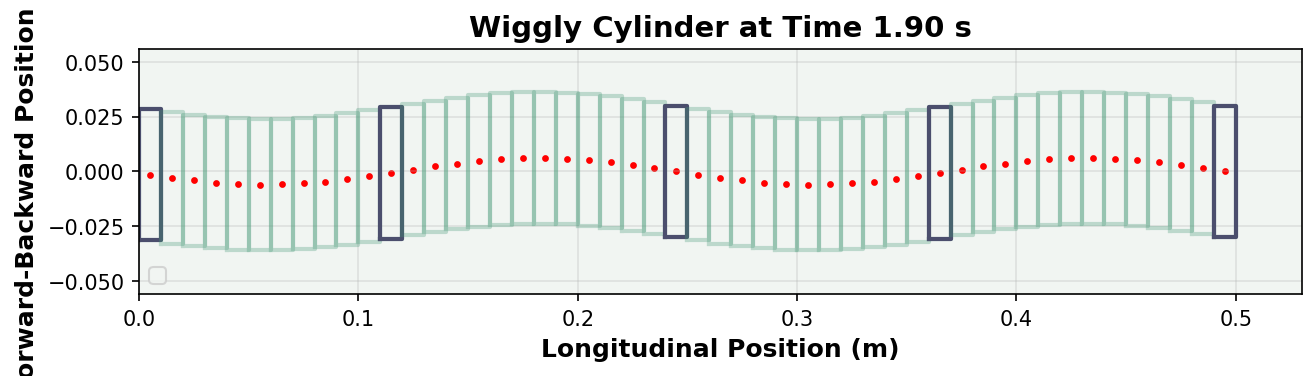

In [49]:

os.makedirs('substack_plots', exist_ok=True)
new_animate(cylinder, path = 'substack_plots/cylinder_standing_wave.mp4', nodes = nodes)